---
title: "PheWAS example - SCZ"
author: Gibran Hemani
date: "2026-05-22"
categories: []
---

In [9]:
library(ieugwasr)
library(TwoSampleMR)
library(dplyr)
library(ggplot2)
scz <- tophits("ieu-b-5100")
str(scz)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




tibble [204 × 12] (S3: tbl_df/tbl/data.frame)
 $ id      : chr [1:204] "ieu-b-5100" "ieu-b-5100" "ieu-b-5100" "ieu-b-5100" ...
 $ trait   : chr [1:204] "Schizophrenia" "Schizophrenia" "Schizophrenia" "Schizophrenia" ...
 $ chr     : chr [1:204] "6" "7" "10" "15" ...
 $ position: int [1:204] 27509493 2029867 104793904 91426560 123669235 2330458 26090270 52815905 103188709 58139593 ...
 $ rsid    : chr [1:204] "rs13195636" "rs58120505" "rs79668541" "rs4702" ...
 $ ea      : chr [1:204] "C" "C" "T" "A" ...
 $ nea     : chr [1:204] "A" "T" "C" "G" ...
 $ eaf     : num [1:204] 0.091 0.446 0.122 0.554 0.741 0.337 0.075 0.476 0.067 0.613 ...
 $ beta    : num [1:204] -0.2105 -0.0833 -0.1207 -0.0803 -0.086 ...
 $ se      : num [1:204] 0.0159 0.0078 0.0121 0.0081 0.0087 0.0085 0.0173 0.0077 0.0168 0.0079 ...
 $ p       : num [1:204] 6.55e-40 1.80e-26 2.11e-23 2.15e-23 3.40e-23 ...
 $ n       : num [1:204] 130644 161405 161405 161405 161405 ...


In [ ]:
l <- list()
for(i in 1:nrow(scz)) {
    message(i)
    if(scz$chr[i] == 6 & scz$position[i] > 25000000 & scz$position[i] < 35000000) {
        message("Skipping MHC region")
        next
    }
    l[[i]] <- phewas(scz$rsid[i], pval = 1e-8, batch=c("ukb-b", "ukb-d"))
}
str(l)
phewas_result <- bind_rows(l)

1

Skipping MHC region

2

3

4

5

6

7

Skipping MHC region

8

9

10

11

12

13

14

15

16

17

18

19

20

21

22

23

24

25

26

27

28

29

30

31

32

33

34

35

36

37

38

39

40

41

42

43

44

45

46

47

48

49

50

51

52

53

54

55

56

57

58

59

60

61

62

63

64

65

66

67

68

69

70

71

72

73

74

75

76

77

78

79

80

81

82

83

84

85

86

87

88

89

90

91

92

93

94

95

96

97

98

99

100

101

102

103

104

105

106

107

108

109

110

111

112

113

114

115

116

117

118

119

120

121

122

123

124

125

126

127

128

129

130

131

132

133

134

135

136

137

138

139

140

141

142

143

144

145

146

147

148

149

150

151

152

153

154

155

156

157

158

159

160

161

162

163

164

165

166

167

168

169

170

171

172

173

174

175

176

177

178

179

180

181

182

183

184

185

186

187

188

189

190

191

192

193

194

195

196

197

198

199

200

201

202

203

204



List of 204
 $ : NULL
 $ : tibble [3 × 12] (S3: tbl_df/tbl/data.frame)
  ..$ id      : chr [1:3] "ukb-d-30770_irnt" "ukb-d-30770_raw" "ukb-d-30830_irnt"
  ..$ trait   : chr [1:3] "IGF-1" "IGF-1" "SHBG"
  ..$ chr     : chr [1:3] "7" "7" "7"
  ..$ position: int [1:3] 2029867 2029867 2029867
  ..$ rsid    : chr [1:3] "rs58120505" "rs58120505" "rs58120505"
  ..$ ea      : chr [1:3] "C" "C" "C"
  ..$ nea     : chr [1:3] "T" "T" "T"
  ..$ eaf     : num [1:3] 0.436 0.436 0.436
  ..$ beta    : num [1:3] 0.0166 0.0922 -0.0139
  ..$ se      : num [1:3] 0.00234 0.01328 0.00229
  ..$ p       : num [1:3] 1.22e-12 3.97e-12 1.04e-09
  ..$ n       : num [1:3] 342439 342439 312215
 $ : tibble [41 × 12] (S3: tbl_df/tbl/data.frame)
  ..$ id      : chr [1:41] "ukb-b-20175" "ukb-b-14057" "ukb-b-14068" "ukb-b-13352" ...
  ..$ trait   : chr [1:41] "Systolic blood pressure, automated reading" "Non-cancer illness code, self-reported: hypertension" "Impedance of leg (left)" "Vascular/heart problems diagnosed by

In [ ]:
# group_by(phewas_result, id) %>%
#     summarise(n = n(), minp = min(p), trait=trait[1]) %>%
#     arrange(desc(n)) %>%
#     select(id, trait, minp, n) %>%
#     write.csv("phewas_result.csv", row.names = FALSE)

In [13]:
phewas_result_filtered <- read.csv("phewas_result.csv") %>% filter(keep == "y")
str(phewas_result_filtered)

'data.frame':	34 obs. of  5 variables:
 $ id   : chr  "ukb-b-19921" "ukb-b-10787" "ukb-b-16446" "ukb-b-16489" ...
 $ trait: chr  "Impedance of whole body" "Standing height" "Basal metabolic rate" "Qualifications: College or University degree" ...
 $ minp : num  3.6e-34 2.4e-37 5.0e-58 2.5e-19 7.1e-33 ...
 $ n    : int  21 13 12 11 9 8 7 6 6 6 ...
 $ keep : chr  "y" "y" "y" "y" ...


In [14]:
allintids <- unique(phewas_result_filtered$id)
int_inst <- extract_instruments(allintids)
outdat <- extract_outcome_data(int_inst$SNP, "ieu-b-5100")
save(scz, outdat, int_inst, allintids, phewas_result_filtered, file = "phewas_result.Rdata")

Warning message in FUN(X[[i]], ...):
“Duplicated SNPs present in exposure data for phenotype 'Diastolic blood pressure, automated reading || id:ukb-b-7992. Just keeping the first instance:
rs28752924”
Warning message in FUN(X[[i]], ...):
“Duplicated SNPs present in exposure data for phenotype 'Mean corpuscular haemoglobin || id:ukb-d-30050_irnt. Just keeping the first instance:
rs2291429”
Extracting data for 7661 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 120

Querying variant chunk 2 of 120

Querying variant chunk 3 of 120

Querying variant chunk 4 of 120

Querying variant chunk 5 of 120

Querying variant chunk 6 of 120

Querying variant chunk 7 of 120

Querying variant chunk 8 of 120

Querying variant chunk 9 of 120

Querying variant chunk 10 of 120

Querying variant chunk 11 of 120

Querying variant chunk 12 of 120

Querying variant chunk 13 of 120

Querying variant chunk 14 of 120

Querying variant chunk 15 of 120

Querying variant chunk 16 of 120


In [16]:
dat1 <- harmonise_data(int_inst, outdat, action=3)
int_mr_res <- mr(dat1, method_list=c("mr_ivw", "mr_wald_ratio"))
int_mr_res %>% arrange(pval) %>% select(exposure, nsnp, b, se, pval)

Harmonising Eosinophill percentage || id:ukb-d-30210_irnt (ukb-d-30210_irnt) and Schizophrenia || id:ieu-b-5100 (ieu-b-5100)

Removing the following SNPs for being palindromic:
rs1000263, rs10810657, rs10893844, rs11071528, rs11236814, rs1131199, rs11701383, rs11701383, rs11807602, rs12206050, rs12463097, rs13045492, rs13078336, rs13251643, rs140074, rs1401884, rs16843291, rs1689510, rs16903574, rs171270, rs17364861, rs175705, rs2158799, rs2383686, rs2807738, rs28421324, rs28469316, rs34053836, rs35311230, rs3848232, rs56195271, rs57199846, rs6013210, rs6031302, rs6672031, rs6820414, rs72771440, rs73681119, rs74612091, rs7649812, rs7789337, rs7846314, rs7986971, rs8140573, rs9266321, rs9468858, rs952558

Removing the following SNPs for incompatible alleles:
rs11701383

Harmonising Total protein || id:ukb-d-30860_irnt (ukb-d-30860_irnt) and Schizophrenia || id:ieu-b-5100 (ieu-b-5100)

Removing the following SNPs for being palindromic:
rs10745495, rs10882100, rs10887917, rs10898811, rs11

exposure,nsnp,b,se,pval
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Duration to first press of snap-button in each round || id:ukb-b-19373,65,0.925718524,0.17124245,6.448595e-08
Neuroticism score || id:ukb-b-4630,105,0.223358364,0.04377137,3.345906e-07
Mean time to correctly identify matches || id:ukb-b-16287,63,0.952603628,0.19091258,6.046149e-07
Age first had sexual intercourse || id:ukb-b-6591,161,-0.439073284,0.10745736,4.388295e-05
Fluid intelligence score || id:ukb-b-5238,71,-0.220840919,0.06156656,3.344695e-04
Past tobacco smoking || id:ukb-b-2134,86,-0.402252907,0.13760590,3.464268e-03
Impedance of whole body || id:ukb-b-19921,454,0.164831081,0.05883142,5.082583e-03
Basal metabolic rate || id:ukb-b-16446,463,-0.163262988,0.05887147,5.550617e-03
Standing height || id:ukb-b-10787,650,-0.089620748,0.03312827,6.824984e-03


`height` was translated to `width`.


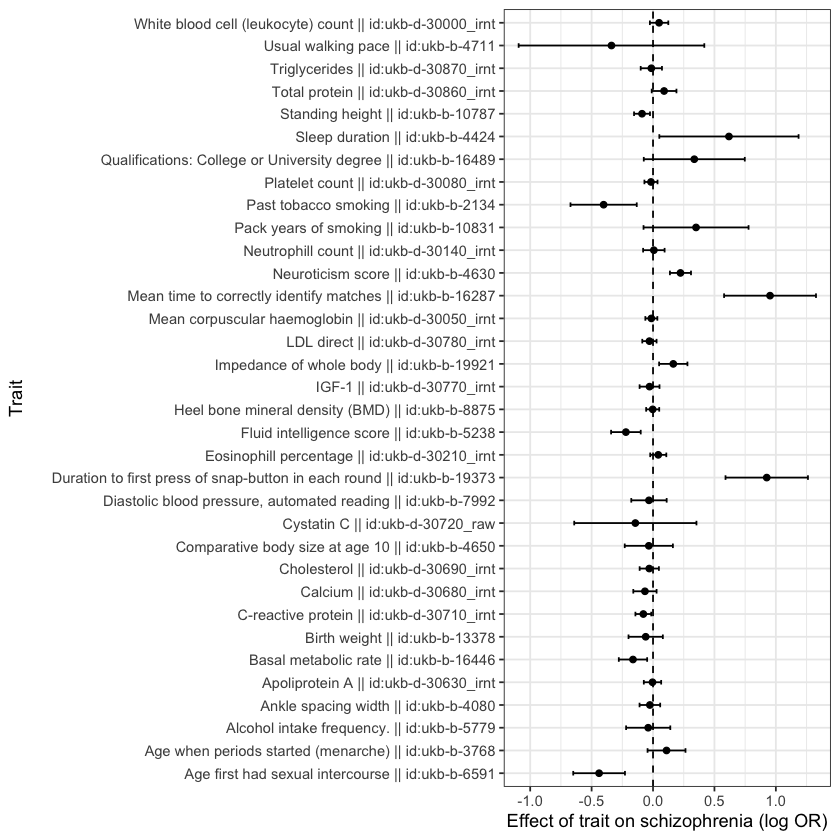

In [18]:
int_mr_res %>% ggplot(., aes(x=b, y=exposure)) + geom_point() + geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se), height=0.2) + theme_bw() + geom_vline(xintercept = 0, linetype="dashed") + xlab("Effect of trait on schizophrenia (log OR)") + ylab("Trait")

In [19]:
dat1 <- steiger_filtering(dat1)

In [20]:
table(dat1$steiger_dir)


FALSE  TRUE 
  283  7569 

In [22]:
int_mr_res <- mr(dat1 %>% filter(steiger_dir), method_list=c("mr_ivw", "mr_wald_ratio"))
int_mr_res %>% arrange(pval) %>% select(exposure, nsnp, b, se, pval) %>% mutate(fdr = p.adjust(pval, method="fdr"))

Analysing 'ukb-d-30210_irnt' on 'ieu-b-5100'

Analysing 'ukb-d-30860_irnt' on 'ieu-b-5100'

Analysing 'ukb-b-6591' on 'ieu-b-5100'

Analysing 'ukb-b-10787' on 'ieu-b-5100'

Analysing 'ukb-d-30000_irnt' on 'ieu-b-5100'

Analysing 'ukb-b-5238' on 'ieu-b-5100'

Analysing 'ukb-b-4080' on 'ieu-b-5100'

Analysing 'ukb-d-30630_irnt' on 'ieu-b-5100'

Analysing 'ukb-b-16446' on 'ieu-b-5100'

Analysing 'ukb-b-19921' on 'ieu-b-5100'

Analysing 'ukb-b-4630' on 'ieu-b-5100'

Analysing 'ukb-d-30050_irnt' on 'ieu-b-5100'

Analysing 'ukb-d-30720_raw' on 'ieu-b-5100'

Analysing 'ukb-b-13378' on 'ieu-b-5100'

Analysing 'ukb-d-30870_irnt' on 'ieu-b-5100'

Analysing 'ukb-d-30080_irnt' on 'ieu-b-5100'

Analysing 'ukb-b-7992' on 'ieu-b-5100'

Analysing 'ukb-b-16287' on 'ieu-b-5100'

Analysing 'ukb-b-3768' on 'ieu-b-5100'

Analysing 'ukb-b-8875' on 'ieu-b-5100'

Analysing 'ukb-d-30690_irnt' on 'ieu-b-5100'

Analysing 'ukb-b-16489' on 'ieu-b-5100'

Analysing 'ukb-b-4650' on 'ieu-b-5100'

Analysing 'ukb-d-3068

exposure,nsnp,b,se,pval,fdr
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Duration to first press of snap-button in each round || id:ukb-b-19373,51,0.5015324595,0.11393322,1.072644e-05,0.0003646988
Neuroticism score || id:ukb-b-4630,88,0.1191708142,0.03132806,1.423989e-04,0.0024207814
Age first had sexual intercourse || id:ukb-b-6591,142,-0.2985911373,0.08157183,2.517544e-04,0.0028532164
Fluid intelligence score || id:ukb-b-5238,67,-0.1396769146,0.05050734,5.683950e-03,0.0483135776
Standing height || id:ukb-b-10787,645,-0.0855744417,0.03228298,8.031074e-03,0.0546113025
Basal metabolic rate || id:ukb-b-16446,452,-0.1365709996,0.05398119,1.140710e-02,0.0595155242
Mean time to correctly identify matches || id:ukb-b-16287,48,0.4024310873,0.16144740,1.267955e-02,0.0595155242
C-reactive protein || id:ukb-d-30710_irnt,157,-0.0728971496,0.02966712,1.400365e-02,0.0595155242
Past tobacco smoking || id:ukb-b-2134,69,-0.1865347038,0.09252131,4.378670e-02,0.1587745321
